In [ ]:
# Переустанавливаем numpy и gensim, чтобы они были совместимы
!pip install --upgrade --force-reinstall numpy gensim
# После этой команды необходимо перезапустить рантайм (Runtime → Restart runtime)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.2/83.2 kB 5.7 MB/s eta 0:00:00
  Attempting uninstall: wrapt
    Found existing installation: wrapt 1.17.2
    Uninstalling wrapt-1.17.2:
      Successfully uninstalled wrapt-1.17.2
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: smart-open
    Found existing installation: s

In [1]:
# Установка необходимых библиотек
!pip install -q pymorphy2 natasha rake-nltk nltk

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.5/55.5 kB 955.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.4/34.4 MB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 35.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 1.1 MB/s eta 0:00:00


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


1. Токенизация (первые 20): ['Как', 'искусственный', 'интеллект', 'влияет', 'на', 'нашу', 'жизнь', 'Ещё', 'десять', 'лет', 'назад', 'искусственный', 'интеллект', 'казался', 'чем', 'то', 'из', 'фантастики', 'Люди', 'говорили']
2. Без стоп-слов (первые 20): ['искусственный', 'интеллект', 'влияет', 'нашу', 'жизнь', 'ещё', 'десять', 'лет', 'назад', 'искусственный', 'интеллект', 'казался', 'фантастики', 'люди', 'говорили', 'роботах', 'которые', 'будут', 'убирать', 'дома']
3. Лемматизация (первые 20): ['искусственный', 'интеллект', 'влиять', 'наш', 'жизнь', 'ещё', 'десять', 'год', 'назад', 'искусственный', 'интеллект', 'казаться', 'фантастика', 'человек', 'говорить', 'робот', 'который', 'быть', 'убирать', 'дом']
4. Именованные сущности:
   - Alexa (ORG)
   - Google (ORG)
   - YouTube (ORG)
   - Netflix (ORG)


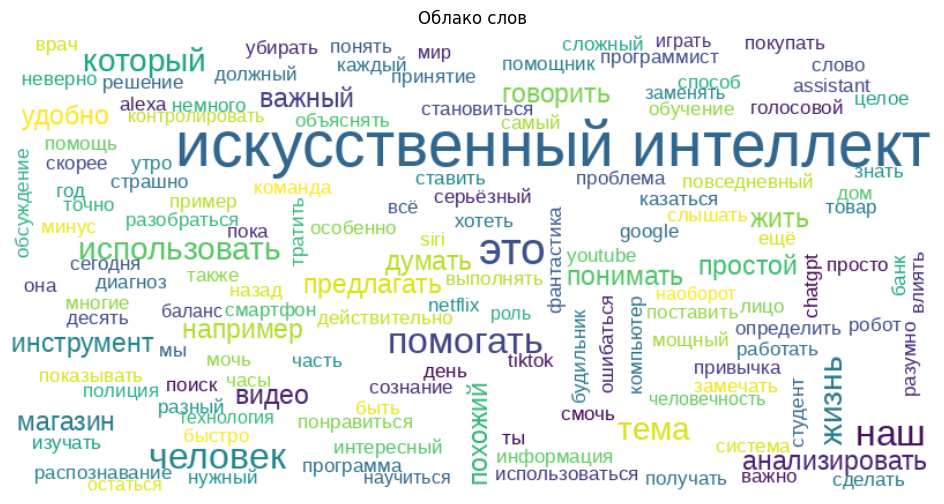

In [8]:
# 1. Подключение диска
from google.colab import drive
drive.mount('/content/drive')

# 2. Импорт библиотек
import nltk
import string
import pymorphy2
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from natasha import Segmenter, NewsEmbedding, NewsNERTagger, Doc
from nltk.corpus import stopwords
from nltk.tokenize import RegexpTokenizer

# 3. Загрузка данных
file_path = '/content/drive/MyDrive/Colab Notebooks/Lab_6/Выборка/test_My.txt'
with open(file_path, 'r', encoding='utf-8') as f:
    text = f.read()

# 4. Загрузка ресурсов
nltk.download('stopwords')

# 5. Токенизация
tokenizer = RegexpTokenizer(r'\w+')
tokens = tokenizer.tokenize(text)

# 6. Удаление стоп-слов
stop_words = set(stopwords.words('russian'))
tokens_no_stop = [t.lower() for t in tokens if t.lower() not in stop_words]

# 7. Лемматизация
morph = pymorphy2.MorphAnalyzer()
lemmas = [morph.parse(token)[0].normal_form for token in tokens_no_stop]

# 8. Именованные сущности (NER)
segmenter = Segmenter()
emb = NewsEmbedding()
ner_tagger = NewsNERTagger(emb)
doc = Doc(text)
doc.segment(segmenter)
doc.tag_ner(ner_tagger)
entities = [(span.text, span.type) for span in doc.spans]

# 9. Облако слов
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    font_path='/usr/share/fonts/truetype/liberation/LiberationSans-Regular.ttf'
).generate(' '.join(lemmas))

# 10. Вывод результатов
print("1. Токенизация (первые 20):", tokens[:20])
print("2. Без стоп-слов (первые 20):", tokens_no_stop[:20])
print("3. Лемматизация (первые 20):", lemmas[:20])
print("4. Именованные сущности:")
for ent in entities:
    print(f"   - {ent[0]} ({ent[1]})")

# 11. Визуализация
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Облако слов')
plt.show()
